In [1]:
import pandas as pd
import cnsplots as cns
import matplotlib.pyplot as plt
from pathlib import Path
import matplotlib.image as mpimg
import cairosvg
import tempfile
import numpy as np
import seaborn as sns
from pathlib import Path
from matplotlib.colors import to_rgb, to_hex
from collections import defaultdict
import os
from openTSNE import TSNE
import joblib
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [2]:
# define constants
COLNAME = "assigned_subcat" # hierarchy level to be analyzed, from here on defined as 'subcategory'
COLNAME_MAP = "Subcategory" # respective column name in the mapping file
TOP_COLNAME = "assigned_top" # hierarchy level to serve as top-level category/mapping
TOP_COLNAME_MAP = "Top_Category" # respective column name in the mapping file

# assertions
assert COLNAME and TOP_COLNAME in ["assigned_subcat", "assigned_cat", "assigned_top"], "Invalid column name. Must be one of 'assigned_subcat', 'assigned_cat', or 'assigned_top'."
assert COLNAME_MAP and TOP_COLNAME_MAP in ["Subcategory", "Category", "Top_Category"], "Invalid column name. Must be one of 'Subcategory', 'Category', or 'Top_Category'."

In [3]:
#######################
# plotting utilities 
#######################

# define colors for top-level categories
topcat_colors = {
    "Assembly": "#007BFF",
    "Structural": "#1e00ff",
    "Host takeover": "#2fff00",
    "NA processing": "#00ffb7",
    "Replication":"#00d9ff",
    "Translation": "#f6ff00",
    "AMGs": "#ffbf00", #"#ffa200",
    "Lysis": "#ff0000", 
    "Anti-Defense": "#ff00dd", 
    "Effectors": "#8e01f9", 
    "Lysogeny": "#FF5A00", #"#ff007b",
    "Unknown": "#bdbdbd", 
}

# define colors for mid-level categories
cat_colors = {
    "Transcriptional regulation": "#2fff00",
    "Transcriptional inhibition": "#02d136",
    "Host resource takeover": "#39fa69",
    "Transcriptional antitermination": "#60c006",
    "Host takeover via phosphorylation": "#3ea52e", 
    "Lytic switch": "#74d216",
    "Transcription factor": "#3C6D0F",
    "Transcriptional machinery": "#0D6806",

    "Integration": "#00ffb7",
    "Excision and transcriptional regulation": "#0dd09c",
    "DNA repair": "#0D916D",
    "Recombination": "#036D51",
    "RNA modification": "#71F8D4",
    "RNA cleavage": "#37F9AF",
    "RNA sealing": "#14AC72",

    "Maintenance": "#FF5A00", #"#ff007b",

    "Protein synthesis": "#f4fa51",
    "Ribosomal protein": "#f3fb00",
    "Translation regulation": "#d0d703",
    "Ribosome biogenesis": "#a0a512",
    "Protein maturation and folding": "#FFFF00",

    "Head morphogenesis": "#4099F9",
    "Head-to-tail joining": "#74B7FE",
    "Tail assembly": "#0F559F",
    "Baseplate assembly": "#014894",
    "DNA packaging": "#0E437B",

    "Replication initiation":"#00d9ff",
    "DNA replication":"#3AAEC3",

    "Capsid": "#1e00ff",
    "DNA injection": "#1903c1",
    "Tail and Fibers": "#553ffb",
    "Baseplate": "#3c2dad",

    "Host polysaccharide degradation": "#e24141", 
    "Endolysin": "#ff0000", 
    "Spanin": "#a90202", 
    "Lysis regulation": "#7D1C1C", 

    "Anti-Restriction": "#ff00dd", 
    "Anti-TA": "#e634f6", 
    "Anti-Defense": "#df00fd",

    "Nucleotide metabolism": "#ffbf00",
    "Other AMGs": "#ff9100",

    "Virulence factors": "#af01f9", 
    "Stress response and damage protection": "#7d01f9", 
    "Membrane transport and signaling": "#a312c3", 
    "Superinfection exclusion": "#710589", 

    "Unknown": "#bdbdbd", 
}


def adjust_color(color, factor=0.2, lighten=True):
    """Mix a color with white or black. The closer the value to 1, the more white/black contained"""
    r, g, b = to_rgb(color)

    if lighten:
        r = r + (1-r)*factor
        g = g + (1-g)*factor
        b = b + (1-b)*factor
    else:
        r = r * (1-factor)
        g = g * (1-factor)
        b = b * (1-factor)

    return to_hex((r, g, b))


def get_factor_range(n, min_n=2, max_n=20, min_spread=0.1, max_spread=0.5):
    """Returns factor range depending on n"""
    # normalize n to 0-1
    t = min(1, max(0, (n - min_n) / (max_n - min_n)))

    spread = min_spread + t * (max_spread - min_spread)

    base = 0.15 
    return base, base+spread


def generate_subcategory_colors(topcat_colors, cat_to_top):
    """Generate colors for subcategories based on their top-level category colors."""
    top_to_sub = defaultdict(list)
    for sub, top in cat_to_top.items():
        top_to_sub[top].append(sub)

    sub_colors = {}

    for top, subs in top_to_sub.items():
        base_color = topcat_colors.get(top, "#999999")
        n = len(subs)

        low, high = get_factor_range(n)

        if n == 1:
            factors = [0.2]
        else:
            factors = np.linspace(low, high, n)

        for i, (sub, factor) in enumerate(zip(subs, factors)):
            lighten = (i % 2 == 0) # alternate
            sub_colors[sub] = adjust_color(base_color, factor, lighten)

    return sub_colors

# lighten top-level category colors
topcat_colors_adjusted = {
    k: adjust_color(v, factor=0.2, lighten=True)
    for k, v in topcat_colors.items()
}

In [4]:
# read mapping file for keywords to sub-, mid-, and top-level categories
keywords_map = pd.read_csv("./input_data/Category_map.csv") 

# create a mapping from subcategories to top-level categories
cat_to_top = keywords_map[[COLNAME_MAP, TOP_COLNAME_MAP]].drop_duplicates().set_index(COLNAME_MAP)[TOP_COLNAME_MAP].to_dict()

/tmp/ipykernel_1419439/4064611742.py:2: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  preds = pd.read_csv("./input_data/Preds_BacVir95_Pharokka_Phold.tsv", sep="\t")
/tmp/ipykernel_1419439/4064611742.py:12: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  reps95 = pd.read_csv("../cnsplots/input_data/all_new_representatives_assigned_cat_0.95.tsv", sep="\t")


153108


/ceph/ibmi/it/thesis_data/scheuren/miniforge3/envs/cnsplots/lib/python3.14/site-packages/cnsplots/_svg.py:101: RuntimeWarning: MuPDF's `mutool` is unavailable; saved a standard matplotlib SVG instead.
  _save_plain_svg(


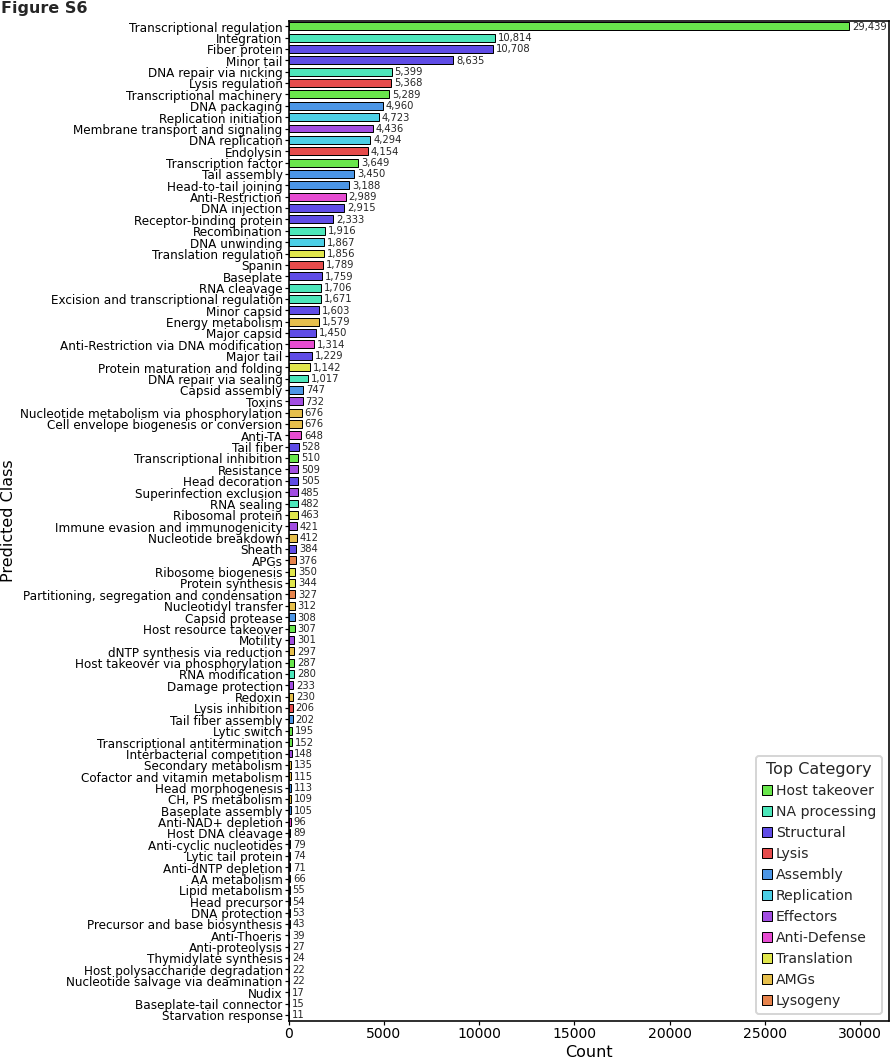

In [7]:
# read in dataframe
preds = pd.read_csv("./input_data/Preds_BacVir95_Pharokka_Phold.tsv", sep="\t")

def clean_df(df, colname):
    """"Helper function to clean the dataframe by replacing entries with semicolons in the specified column with 'Unknown'."""
    mask = df[colname].str.contains(";")
    df.loc[mask, colname] = "Unknown"
    return df

preds = clean_df(preds, "assigned_subcat_initial")

reps95 = pd.read_csv("../cnsplots/input_data/all_new_representatives_assigned_cat_0.95.tsv", sep="\t")
reps95_phage = reps95[reps95["table_origin"] == "phg"]

preds95 = preds[preds["protein_ID"].isin(reps95_phage["protein_ID"])]
preds95_unknome = preds95[preds95["assigned_subcat_initial"] == "Unknown"].sort_values(["P(Predicted)"], ascending=False)

print(len(preds95_unknome))

sns.set_theme(style="whitegrid", palette="viridis")

counts = preds95_unknome["Predicted Class"].value_counts().reset_index()
counts.columns = ["Predicted Class", "Frequency"]
counts["Top_Cat"] = counts["Predicted Class"].map(cat_to_top)


cns.settings.title_fontweight = "normal"
mp = cns.multipanel(
    max_width=600, title="Figure S6", title_fontweight="bold", loc="left"
)

mp.panel("", 300, 500)
ax = plt.gca()
sns.barplot(data=counts, x="Frequency", y="Predicted Class", errorbar=None, hue="Top_Cat", palette=topcat_colors_adjusted, dodge=False, edgecolor="black", lw=0.5, width=0.7)

# Add counts next to bars
for i, count in enumerate(counts["Frequency"]):
    ax.text(count+150,   # distance from end of bar
        i, f"{count:,}", va="center", fontsize=5)

ax.set_xlim(right=counts["Frequency"].max() * 1.07)
ax.set_xlabel("Count")
ax.set_ylabel("Predicted Class")
ax.tick_params(axis="x")
ax.tick_params(axis="y", labelsize=6)

ax = plt.gca()

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(0.8)

ax.legend(frameon=True, title="Top Category", bbox_to_anchor=(1, 0), loc="lower right")

# Save final figure
outdir = Path("./plots/")
outdir.mkdir(parents=True, exist_ok=True)
cns.savefig(outdir / "FigureS6.svg")